In [ ]:
# @TODO:
#   - MC on-policy iteration
#     - sample-average
#     - weighted-average
#   - MC off-policy iteration
#     - ordinary importance sampling
#     - weighted importance sampling
#     - discounting-aware importance sampling (weighted)
#     - per-decision importance sampling (ordinary)
#   - MC for gridworld
#   - MC for blackjack

In [1]:
from IPython.display import Image

from matplotlib import pyplot as plt
import numpy as np
from numpy.random import normal, binomial, choice
import pandas as pd
from scipy import stats
import seaborn as sns


px = 1 / plt.rcParams["figure.dpi"]  # pixel in inches
plt.rcParams["figure.figsize"] = (600 * px, 400 * px)
%matplotlib widget

## Chapter 5: Monte Carlo Methods

- **Monte Carlo (MC) methods** are learning methods for estimating value functions and discovering optimal policies based on averaging sample returns, useful for cases where we do not have access to or do not want to compute the complete dynamics of the environment.
  
  - To ensure that well-defined returns are available, here we define MC methods only for episodic tasks.
  
  - Only on the completion of an episode are value estimates and/or policies updated.
  
  - The term "Monte Carlo" is often used broadly for any estimation method involving sampling averaging with a random component: here we use it specifically for estimation methods based on learning from averaging _complete_ returns (as opposed to learning from _partial_ returns, as in **TD learning**.)

- MC methods sample and average returns for each state-action pair, similar to the way bandit methods sample and average individual rewards for each action.

- We adapt the idea of general policy iteration (GPI) developed in Chapter 4 for dynamic programming (DP).
  
  - In DP we _computed_ value functions from complete knowledge of the MDP; in MC we _learn_ value functions from sample interactions (episodes with returns) with the MDP. 

## 5.1 Monte Carlo Prediction (Policy Evaluation)

- MC methods learn the state-value function for a given policy via averaging the returns observed after visits to each state, respectively. By the law of large numbers, as more returns are observed, this average should converge to the E.V.

- Two $v_\pi(s)$ MC estimation methods:
  
  - **First-visit MC**: estimates $v_\pi(s)$ as the average of the returns following only first visits to $s$ within an episode.
  
  - **Every-visit MC**: estimates $v_\pi(s)$ as the average of the returns following each visit to $s$ within an episode.
  
  - Every-visit MC extends more naturally to function approximation and eligibility traces (discussed in Chapters 9 and 12), but for simplicity we focus on first-visit MC in this chapter.

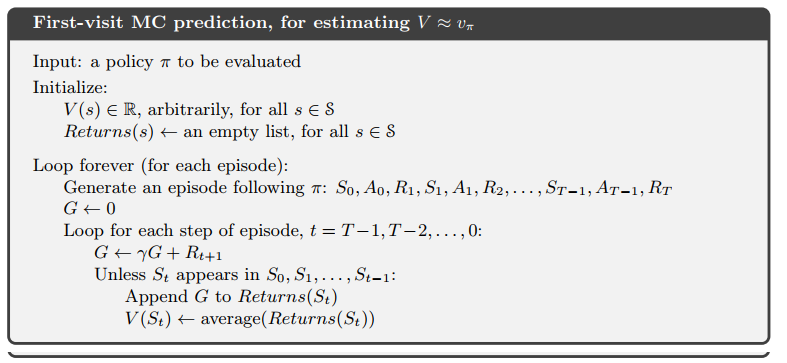

In [5]:
Image(r"images/first_visit_pseudocode.png", width=700)

### 5.1 Exercises

## 5.2 Monte Carlo Estimation of Action-Values

- With a complete model of the environment, _state_ values alone are sufficient to improve a policy via one-step lookahead; without a model, however, we cannot accurately perform this one-step lookahead, so we estimate _action_ values in order to improve a policy: thus one of the primary goals of MC methods is to estimate $q_*$.
  
  - The MC methods for this are essentially the same as for estimating $v$, except now we consider visits to a state-action pair rather than just to a state.
  
  - One complication is that many state-action pairs may never be visited, particularly if $\pi$ is a deterministic policy. 
    
    - One way to combat this general problem of maintaining exploration is to build-in **exploring starts**: specify that each episode starts in a state-action pair, and every possible pair has a nonzero probability of being selected: over a large enough number of episodes, every state-action pair will thus be visited.
    
    - Another common alternative is to consider policies that are stochastic and with nonzero probabilities of selecting all possible state-action pairs.
      
      - These can take the form of **on-policy** or **off-policy** methods, which will be discussed in later sections in this chapter.

## 5.3 Monte Carlo Control (Policy Iteration)

- If 1. we use exploring starts or a stochastic policy, and 2. we run an infinite number of episodes, then policy iteration using Monte Carlo estimation is guaranteed to yield an optimal policy.

- We can combine exploring starts with first- or every-visit MC to get GPI for MC
action-value estimation.

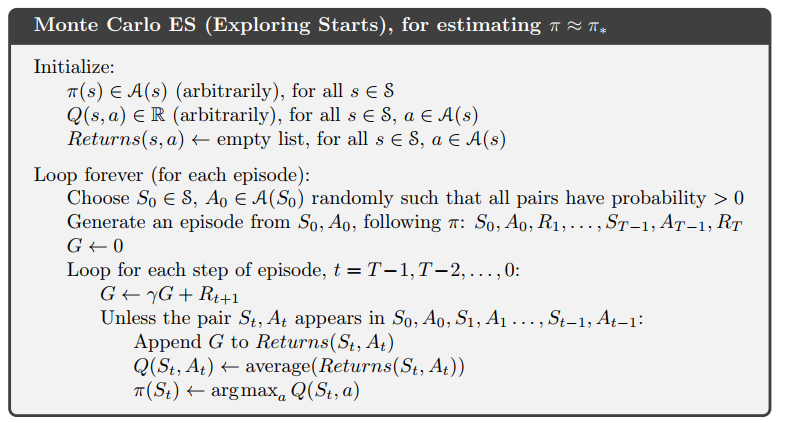

In [7]:
Image(r"images/monte_carlo_es_pseudocode.png", width=700)

## 5.4 On-policy Monte Carlo Control without Exploring Starts

- If we don't use exploring starts but we still want to ensure that all state-actions
are selected, we can use **stochastic on-policy or off-policy** methods.

  - On-policy methods: evaluate / improve the current policy that is being used

    - (*Note*: **MCES** can be considered an on-policy method, but we want to in particular here explore on-policy methods outside of just the start of an episode.)
  
  - Off-policy methods: evaluate / improve a policy different to the current one

- As we did in Chapter 2 with Bandits, we can use an **$\epsilon \text{-} greedy$ policy as an MC on-policy method**.

  - (*Terminology note*: policies where $\pi (a|s) > 0 $ for each $s \in S$ and each $a \in A(s)$ are called **soft policies**.)

- Using GPI with MCwoES, we don't move our policy all the way to a greedy policy, but _toward_ a greedy policy, by moving it to an $\epsilon \text{-} greedy$ policy.


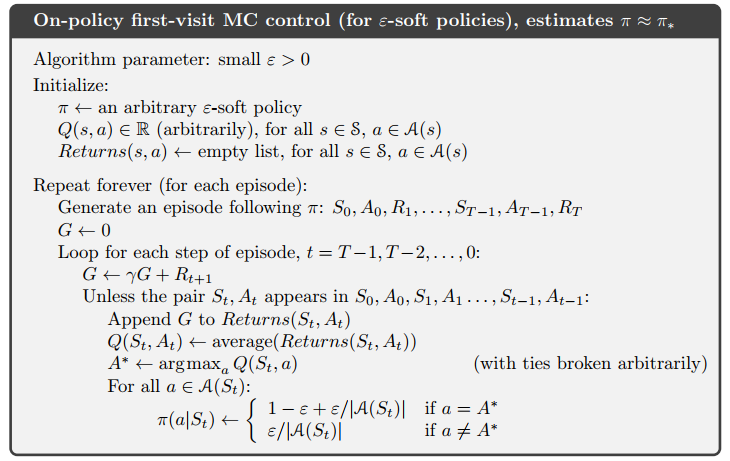

In [4]:
Image(r"images/MCwoES_egreedy.png", width=700)

## 5.5 Off-policy Prediction via Importance Sampling

- Off-policy learning attempts to learn an optimal, **target policy** by using a different, exploratory **behavior policy**: we say that learning is from data "off" the target policy.

- Because off-policy methods use two policies at a time, they are often of greater variance and slower to converge, but can often solve more complex problems and are more general.

- Here, we begin the study of off-policy methods by considering the **prediction problem**, in which both target ($\pi$) and behavior ($b$) policies are fixed, and we want to estimate $v_\pi$ and $q_\pi$ from $b$. (Another common off-policy approach is a deterministic, greedy target policy, with $\epsilon \text{-} greedy$ behavior policy.)

  - **Coverage assumption**: Every action taken under $\pi$ must also be possible under $b$.

  - **Importance sampling**: Estimating E.V. under one distribution (target policy, in this case) given samples from another (behavior policy, in this case).

    - **Importance-sampling ratio**: The weights of the returns according to the relative probability of their trajectories occurring under the target and behavior policies: 
    $$ 
    \rho_t:T-1 = \prod_{k=t}^{T-1} \frac{\pi(A_k|S_k)}{b(A_k|S_k)} \tag{5.3}
    $$

      - The importance-sampling ratio, $\rho_t:T-1$, transforms the behavior policy returns to have the correct E.V. for an estimation of the target policy returns:
      $$
      \mathbb{E}[(\rho_t:T-1) G_t^{b} | S_t = s] = v_\pi(s) \tag{5.4}
      $$
    
    - Define terms for MC sampling algorithms:
      
      - Let $t$ denote the set of timestamps across episodes
      
      - Let $\mathcal{T}(s)$ denote the set of all time steps in which state $s$ is visited

      - Let $G_{t}^{b}$ denote the return after $t$ up through $T(t)$ (the first episode termination after $t$)

      - Then $\{G_{t}^{b}\}_{t \in \mathcal{T}(s)}$ are the returns for state $s$ 

      - And $\{\rho_t: T(t) - 1 \}_{t \in \mathcal{T}(s)}$ are the corresponding importance-sampling ratios
    
    - **Ordinary importance sampling** scales the returns by the ratios and averages the results:
    $$
    V(s) = \frac{\sum_{t \in \mathcal{T}(s)} (\rho_t: \mathcal{T}(t) - 1) G_{t}^{b} }{\lvert\mathcal{T}(s)\rvert} \tag{5.5}
    $$

    - **Weighted importance sampling** scales the returns by the ratios and a weighted average:
    $$
    V(s) = \frac{\sum_{t \in \mathcal{T}(s)} (\rho_t: \mathcal{T}(t) - 1) G_{t}^{b} }{\sum_{t \in \mathcal{T}(s)} \rho_t: \mathcal{T}(t) - 1} \tag{5.6}
    $$

  - Consequences of each type of importance sampling:

    - Weighted: The estimate of a single return is $G_t^b$, and in this statistical sense it is biased to $v_b(s)$ rather than $v_\pi(s)$

    - Ordinary: This estimator is unbiased, but can be extreme: suppose the ratio is 10, indicating that the observed trajectory is 10x more likely under $\pi$ than $b$, and we're creating an estimate following a first-visit method after observing a single return from state $s$; then, the importance-sampling estimate would be 10x the observed return, even though the trajectory may be very representative of the target policy.

    - Formally, the difference between the first-visit methods of each of these sampling types is: ordinary is unbiased but unbounded, whereas weighted is biased but bounded (the largest weight on any single return is 1).

    - In practice, the weighted estimator typically has dramatically lower variance, and is preferred.

- Off-policy methods _may_ outperform on-policy by:

  1. Improving data utilization / sample efficiency 

  2. Enabling learning across experiences and across time (i.e. transfer learning)

  - Some examples:

    - Exploration-Exploitation Balance example: A robot learning to navigate a maze with sparse rewards. 
      
      - Why off-policy can be better: An off-policy method like Q-learning can learn from exploratory actions (e.g., random movements) while still updating the optimal policy. This allows for better exploration of the environment without sacrificing the quality of the learned policy.

    - Multi-task Learning example: A household robot learning multiple tasks simultaneously. 
    
      - Why off-policy can be better: Off-policy methods can learn from experiences gathered while performing various tasks. For instance, data collected while cleaning can inform learning about cooking tasks, maximizing data efficiency.

    - Continuous Learning in Dynamic Environments example: A stock trading AI adapting to market changes. 
    
      - Why off-policy can be better: Off-policy methods can continue learning from past experiences even as the environment (market conditions) changes, maintaining a balance between adapting to new information and retaining valuable past knowledge.



## 5.6 Incremental Implementation of MC Prediction (Policy Evaluation)

- In on-policy MC, we can average _returns_ incrementally to update value estimates, similar to how we averaged _rewards_ to incrementally update value estimates for Bandits in [2.4](../ch2/ch2.ipynb#2.4-Incremental-Implementation) (sample-average method) and [2.5](../ch2/ch2.ipynb#2.5-Tracking-a-Nonstationary-Problem) (weighted-average method), as shown in [5.3](#5.3-monte-carlo-control-policy-iteration)

- For off-policy MC:

  - For ordinary importance sampling: simple averaged scaled returns

  - For weighted importance sampling, we wish to form the value estimate after $n$ returns:
    $$
    V_n = \frac{\sum_{k=1}^{n-1} W_k G_k}{\sum_{k=1}^{n-1} W_k}, \quad n \geq 2 \tag{5.7}
    $$
  and so our update rule is:
    $$
    V_{n+1} = V_n + \frac{W_n}{C_n} \left[ G_n - V_n \right], \quad n \geq 1 \tag{5.8}
    $$ 
  where $C_{n+1} = C_n + W_{n+1}$ where $C_n$ is the cumulative sum of the weights of the returns up to the $n$-th return



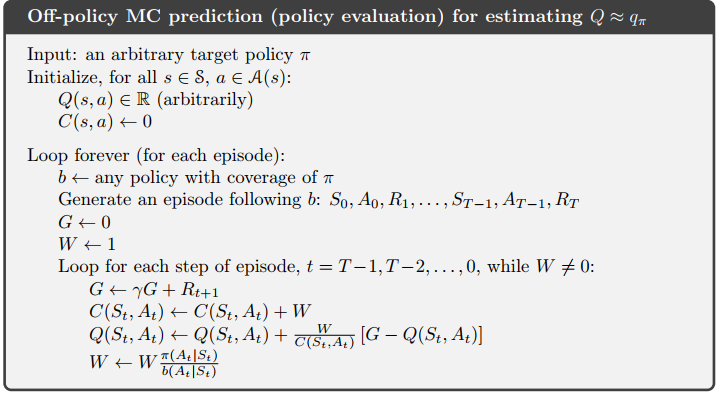

In [5]:
Image(r"images/mc_off-policy_evaluation.png", width=700)

## 5.7 Off-policy MC Control (Policy Iteration)

- The below algorithm implements off-policy MC control with weighted importance sampling
  
  - $Q$ is an estimate of $q_\pi$, and the target policy $\pi \approx \pi_*$ is greedy w.r.t $Q$.

  - $b$ can be anything that has coverage of $\pi$; here we choose $b$ to be $\epsilon$-soft

  - $\pi$ will converge to optimal at all encountered states, even though actions are chosen by $b$, and $b$ itself may change between or even within episodes.


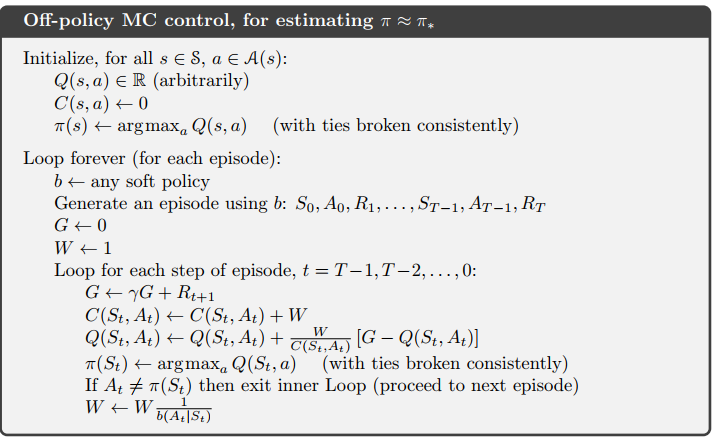

In [7]:
Image(r"images/mc_off-policy_iteration.png", width=700)

## 5.8 Discounting-aware Importance Sampling

- Potential problems of the above off-policy MC iteration are:
  
  1. If non-greedy actions are common, learning will be slow, particularly for states appearing early in long episodes.

  2. The variance of the estimator can be high.

- For $\gamma << 1$, one way to counteract this is with **discounting-aware importance sampling**

  - As an example, consider an episode that lasts 100 steps with $\gamma = 0$ : the return will always just be $R_1$, but its importance sampling ratio will be a product of 100 factors: $\frac{\pi(A_0|S_0)}{b(A_0|S_0)} ... \frac{\pi(A_{99}|S_{99})}{b(A_{99}|S_{99})}$, but we could ignore the last 99 factors because they do not change the expected value, they only add to its variance.

  - To avoid this large extraneous variance, we can implement discounting-aware importance sampling, where we early terminate the importance sampling calculation at some timestep horizon $h$ that is less than $T$.

    - To calculate $h$, we can employ various methods; one approach is to check the cumulative reward over a window of steps - we could choose $h$ as the timestep at which the cumulative reward from each / all of the last $N$ steps was below some threshold, $\upsilon$.

    - The full return can then be viewed as: $G_t^b$ = $(1-\gamma) (\sum_{h=t+1}^{T-1} \gamma^{h-t-1} \tilde{G}_{t:h}) + \gamma^{T-t-1} \tilde{G}_{t:T}$

      - With an ordinary importance sampling estimator: 
        $$
        V(s) = \frac{\sum_{t \in \mathcal{T}(s)} \left( (1-\gamma) (\sum_{h=t+1}^{T(t)-1} \gamma^{h-t-1} \rho_{t:h-1} \tilde{G}_{t:h}) + \gamma^{T(t)-t-1} \rho_{t:T(t)-1} \tilde{G}_{t:T(t)} \right)}{|\mathcal{T}(s)|} \tag{5.9}
        $$

      - And a weighted importance sampling estimator:
        $$
        V(s) = \frac{\sum_{t \in \mathcal{T}(s)} \left( (1-\gamma) (\sum_{h=t+1}^{T(t)-1} \gamma^{h-t-1} \rho_{t:h-1} \tilde{G}_{t:h}) + \gamma^{T(t)-t-1} \rho_{t:T(t)-1} \tilde{G}_{t:T(t)} \right)}{\sum_{t \in \mathcal{T}(s)} \left( (1-\gamma) (\sum_{h=t+1}^{T(t)-1} \gamma^{h-t-1} \rho_{t:h-1}) + \gamma^{T(t)-t-1} \rho_{t:T(t)-1} \right)} \tag{5.10}
        $$
      
      - In all of these cases, we sum up the importance sampling of the partial returns for each timestep up to timestep $h$, and then simply add the 'final' partial return from $h$ to $T$ as a single term, for each $t$ in which $s$ was visited.



## 5.9 Per-decision Importance Sampling

- Another way in which the structure of the return as a sum of rewards can be taken into account in off-policy importance sampling is to apply the importance sampling at each timestep within the episode: instead of multiplying the importance sampling ratio across the entire return, each step is weighted individually, and the rewards adjusted incrementally.
  
  - This can reduce high variance that can result e.g. from particularly long episodes in which small differences between $\pi$ and $b$ at each step can accumulate multiplicatively across the entire return.

  - $\mathbb{E}[\rho_{t:T-1}G_t]$ can be written as $\mathbb{E}[\bar{G}_t]$, where:
  
    $\bar{G}_t = \gamma^0 \rho_{t:t}R_{t+1} + \gamma^1 \rho_{t:t+1}R_{t+2} + ... + \gamma{T-t-1} \rho_{t:T-1}R_T$
  
  - Then, our **per-decision ordinary importance sampling** estimator is:
    $$
    V(s) = \frac{\sum_{t \in \mathcal{T}(s)} \bar{G}_t}{|\mathcal{T}(s)|} \tag{5.15}
    $$

    - This can reduce variance even in the absence of discounting (i.e. even when $\gamma = 1$)
  
  - For per-decision _weighted_ importance sampling estimators, those that have been proposed are **not consistent** (they do not converge to the true optimal state value with infinite data)